## Experimentation avec séquence Halton

Ce notebook investigue la couverture des samples aléatoire vs séquence d'Halton.

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
def halton_sequence(b):
    """Generator function for Halton sequence."""
    n, d = 0, 1
    while True:
        x = d - n
        if x == 1:
            n = 1
            d *= b
        else:
            y = d // b
            while x <= y:
                y //= b
            n = (b + 1) * y - x
        yield n / d

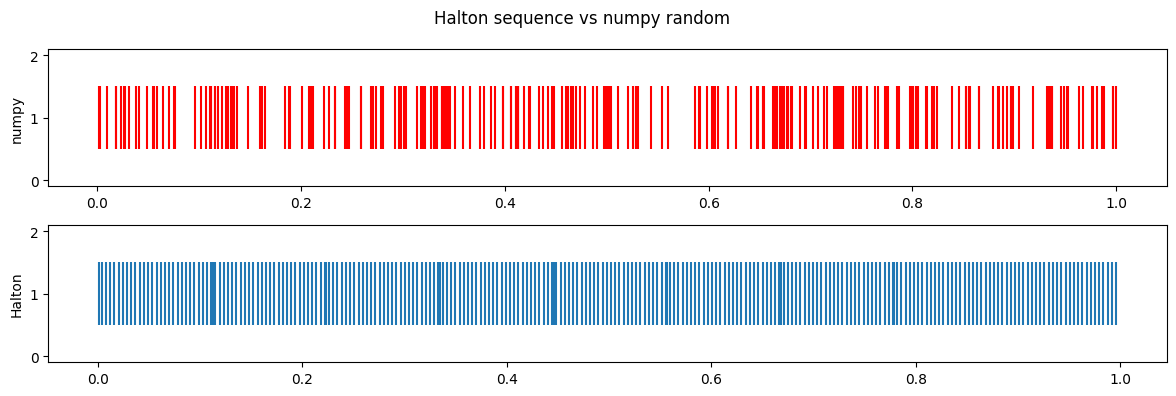

In [5]:
import itertools

NUM = 250

data_hal = [n for n in itertools.islice(halton_sequence(3), NUM) ]
data_np  = np.random.uniform(size=NUM)
y        = np.ones(NUM)

plt.figure(figsize=(12, 4))

plt.subplot(211)
plt.eventplot(data_np, colors="red")
plt.ylabel("numpy")

plt.subplot(212)
plt.eventplot(data_hal)
plt.ylabel("Halton")

plt.suptitle("Halton sequence vs numpy random")
plt.tight_layout()
plt.show()